In [1]:
import sys
from pathlib import Path
from copy import copy

import numpy as np
import pandas as pd
import cv2 as cv
from cv2.typing import MatLike, TermCriteria
import matplotlib.pyplot as plt
from matplotlib import __version__ as matplotlib_version
import seaborn as sns

import torch
from torch import nn
from torch import optim

from utils.imageio import read_images
from utils.evaluate import evaluate_metrics, evaluate_neural_network
from utils.train import train_neural_network
from utils.pipeline import ImagePipeline, ImageState
from utils.types import ArrayLike, Tensors
from utils.cnn import UNet
from utils.visualization import plot_loss_curve, plot_confusion_matrix

In [2]:
print(f"Using python version: {sys.version}")
print(f"Using numpy version: {np.__version__}")
print(f"Using pytorch version {torch.__version__}")
print(f"Using pandas version {pd.__version__}")
print(f"Using opencv version: {cv.__version__}")
print(f"Using matplotlib version {matplotlib_version}")
print(f"Using seaborn version {sns.__version__}") # type: ignore


Using python version: 3.12.12 (main, Feb 12 2026, 00:42:34) [Clang 21.1.4 ]
Using numpy version: 2.4.3
Using pytorch version 2.10.0
Using pandas version 3.0.1
Using opencv version: 4.13.0
Using matplotlib version 3.10.8
Using seaborn version 0.13.2


In [3]:
DATA_PATH = Path("../datasets/EWS-Dataset")
TRAIN_PATH = DATA_PATH / "train"
VAL_PATH = DATA_PATH / "validation"
TEST_PATH = DATA_PATH / "test"

MODEL_PATH = Path("../models")

LOWER_GREEN = np.array([35, 40, 40])
UPPER_GREEN = np.array([90, 255, 255])

SEED = 42

In [4]:
train_x, train_y = read_images(TRAIN_PATH)
val_x, val_y = read_images(VAL_PATH)
test_x, test_y = read_images(TEST_PATH)
print(train_x[0].shape)
assert len(val_x) == len(val_y)
assert len(train_x) == len(train_y)
assert len(test_x) == len(test_y)

(352, 352, 3)


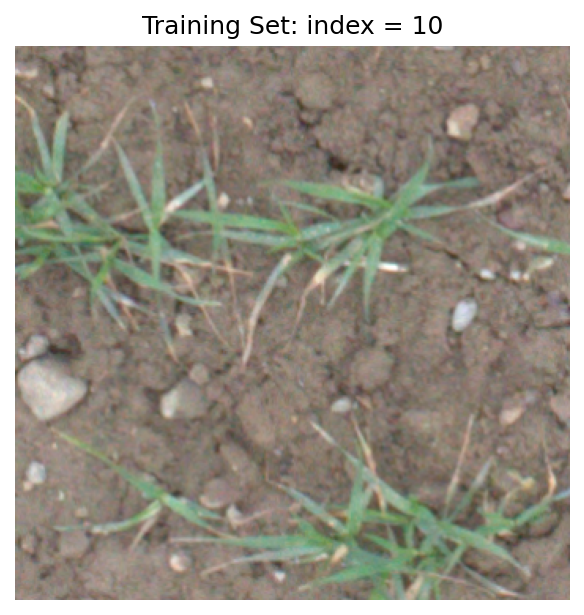

In [5]:
train_pipeline = ImagePipeline(train_x, ImageState.RGB, "Training Set")
train_y_pipeline = ImagePipeline(train_y, ImageState.BINARY, "Training Y")
val_pipeline = ImagePipeline(val_x, ImageState.RGB, "Validation Set")
test_pipeline = ImagePipeline(test_x, ImageState.RGB, "Test Set")

train_pipeline.show(10)

### Traditional CV

In [6]:
def hsv_segmentation(
        pipeline: ImagePipeline,
        lower: MatLike,
        upper: MatLike,
        kernel_size: tuple[int, int],
        iters: int
    ) -> ImagePipeline:
    assert pipeline.image_state == ImageState.RGB
    processing_pipeline = pipeline.copy()
    return processing_pipeline.rgb_to_hsv() \
        .in_color_range(lower, upper) \
        .opening(kernel_size, iters=iters) \
        .closing(kernel_size, iters=iters)

hsv_segmented_train = hsv_segmentation(train_pipeline, LOWER_GREEN, UPPER_GREEN, (3, 3), 1)
hsv_segmented_val = hsv_segmentation(val_pipeline, LOWER_GREEN, UPPER_GREEN, (3, 3), 1)
hsv_segmented_test = hsv_segmentation(test_pipeline, LOWER_GREEN, UPPER_GREEN, (3, 3), 1)


_ = evaluate_metrics(hsv_segmented_train.images, train_y, print_metrics=True, custom_title="HSV Train")
_ = evaluate_metrics(hsv_segmented_val.images, val_y, print_metrics=True, custom_title="HSV Validation")
_ = evaluate_metrics(hsv_segmented_test.images, test_y, print_metrics=True, custom_title="HSV Test")


Evaluation Result for **HSV Train**:

True Positive: 2541772
True Negative: 13626218
False Positive: 275639
False Negative: 1150739

Accuracy: 0.92
Precision: 0.90
Recall: 0.69
F1: 0.78


Evaluation Result for **HSV Validation**:

True Positive: 729044
True Negative: 1980543
False Positive: 66874
False Negative: 197235

Accuracy: 0.91
Precision: 0.92
Recall: 0.79
F1: 0.85


Evaluation Result for **HSV Test**:

True Positive: 741928
True Negative: 1926202
False Positive: 72541
False Negative: 233025

Accuracy: 0.90
Precision: 0.91
Recall: 0.76
F1: 0.83



In [7]:
def kmeans_method(
        processing_pipeline: ImagePipeline,
        k: int,
        criteria: TermCriteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
        ) -> ImagePipeline:
    return processing_pipeline.k_means_clustering(k, criteria)

kmeans_segmented_train = kmeans_method(train_pipeline, k=2)
kmeans_segmented_val = kmeans_method(val_pipeline, k=2)
kmeans_segmented_test = kmeans_method(test_pipeline, k=2)


_ = evaluate_metrics(kmeans_segmented_train.images, train_y, print_metrics=True, custom_title="K-means Train")
_ = evaluate_metrics(kmeans_segmented_val.images, val_y, print_metrics=True, custom_title="K-means Validation")
_ = evaluate_metrics(kmeans_segmented_test.images, test_y, print_metrics=True, custom_title="K-means Test")


Evaluation Result for **K-means Train**:

True Positive: 1805639
True Negative: 8223121
False Positive: 5678736
False Negative: 1886872

Accuracy: 0.57
Precision: 0.24
Recall: 0.49
F1: 0.32


Evaluation Result for **K-means Validation**:

True Positive: 355215
True Negative: 1331004
False Positive: 716413
False Negative: 571064

Accuracy: 0.57
Precision: 0.33
Recall: 0.38
F1: 0.36


Evaluation Result for **K-means Test**:

True Positive: 355537
True Negative: 1134253
False Positive: 864490
False Negative: 619416

Accuracy: 0.50
Precision: 0.29
Recall: 0.36
F1: 0.32



In [19]:
def edge_method(
        process_pipeline: ImagePipeline,
        blur_ksize: tuple[int, int] = (5, 5),
        blur_stddev: float = 1.4,
        edge_th1: int = 60,
        edge_th2: int = 150,
        closing_ksize: tuple[int, int] = (3, 3),
        closing_iter = 5,
        remove_object_size = 1000
    ) -> ImagePipeline:

    return process_pipeline \
        .gaussian_blur(blur_ksize, blur_stddev) \
        .canny_edge_detect(edge_th1, edge_th2) \
        .closing(closing_ksize, closing_iter) \
        .remove_small_object(remove_object_size)

edge_segmented_train = edge_method(train_pipeline)
edge_segmented_val = edge_method(val_pipeline)
edge_segmented_test = edge_method(test_pipeline)

_ = evaluate_metrics(edge_segmented_train.images, train_y, print_metrics=True, custom_title="Edge Train Set")
_ = evaluate_metrics(edge_segmented_val.images, val_y, print_metrics=True, custom_title="Edge Validation Set")
_ = evaluate_metrics(edge_segmented_test.images, test_y, print_metrics=True, custom_title="Edge Test Set")


Evaluation Result for **Edge Train Set**:

True Positive: 1962217
True Negative: 9397214
False Positive: 4504643
False Negative: 1730294

Accuracy: 0.65
Precision: 0.30
Recall: 0.53
F1: 0.39


Evaluation Result for **Edge Validation Set**:

True Positive: 403545
True Negative: 1430343
False Positive: 617074
False Negative: 522734

Accuracy: 0.62
Precision: 0.40
Recall: 0.44
F1: 0.41


Evaluation Result for **Edge Test Set**:

True Positive: 421572
True Negative: 1313113
False Positive: 685630
False Negative: 553381

Accuracy: 0.58
Precision: 0.38
Recall: 0.43
F1: 0.40



In [7]:
def exessive_green_method(process_pipeline: ImagePipeline, threshold: int = 20, remove_object_size: int = 100) -> ImagePipeline:
    return process_pipeline \
        .excessive_green_mask(threshold) \
        .remove_small_object(remove_object_size)

ExG_segmented_train = exessive_green_method(train_pipeline)
ExG_segmented_val = exessive_green_method(val_pipeline)
ExG_segmented_test = exessive_green_method(test_pipeline)

_ = evaluate_metrics(ExG_segmented_train.images, train_y, print_metrics=True, custom_title="ExG Train Set")
_ = evaluate_metrics(ExG_segmented_val.images, val_y, print_metrics=True, custom_title="ExG Validation Set")
_ = evaluate_metrics(ExG_segmented_test.images, test_y, print_metrics=True, custom_title="ExG Test Set")


Evaluation Result for **ExG Train Set**:

True Positive: 3056316
True Negative: 13231362
False Positive: 670495
False Negative: 636195

Accuracy: 0.93
Precision: 0.82
Recall: 0.83
F1: 0.82


Evaluation Result for **ExG Validation Set**:

True Positive: 835134
True Negative: 1889333
False Positive: 158084
False Negative: 91145

Accuracy: 0.92
Precision: 0.84
Recall: 0.90
F1: 0.87


Evaluation Result for **ExG Test Set**:

True Positive: 880797
True Negative: 1804906
False Positive: 193837
False Negative: 94156

Accuracy: 0.90
Precision: 0.82
Recall: 0.90
F1: 0.86



In [8]:
device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "mps" if torch.mps.is_available() else "cpu"
)

BATCH_SIZE = 3

In [22]:
loss_func = nn.BCEWithLogitsLoss()
unet = UNet().to(device)
optimiser = optim.Adam(unet.parameters(), lr=1e-4)

train_data = train_pipeline.get_data_loader(ground_truth=train_y, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
val_data = val_pipeline.get_data_loader(ground_truth=val_y, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)

unet, train_log, val_log = train_neural_network(
    train_data,
    val_data,
    unet,
    loss_func,
    optimiser,
    epochs=40,
    patience=5,
    min_delta=1e-4,
    device=device,
)


epoch 10 | train loss: 0.183591 | val loss 0.183155
epoch 20 | train loss: 0.168194 | val loss 0.156357
Early Stopping at epoch 27


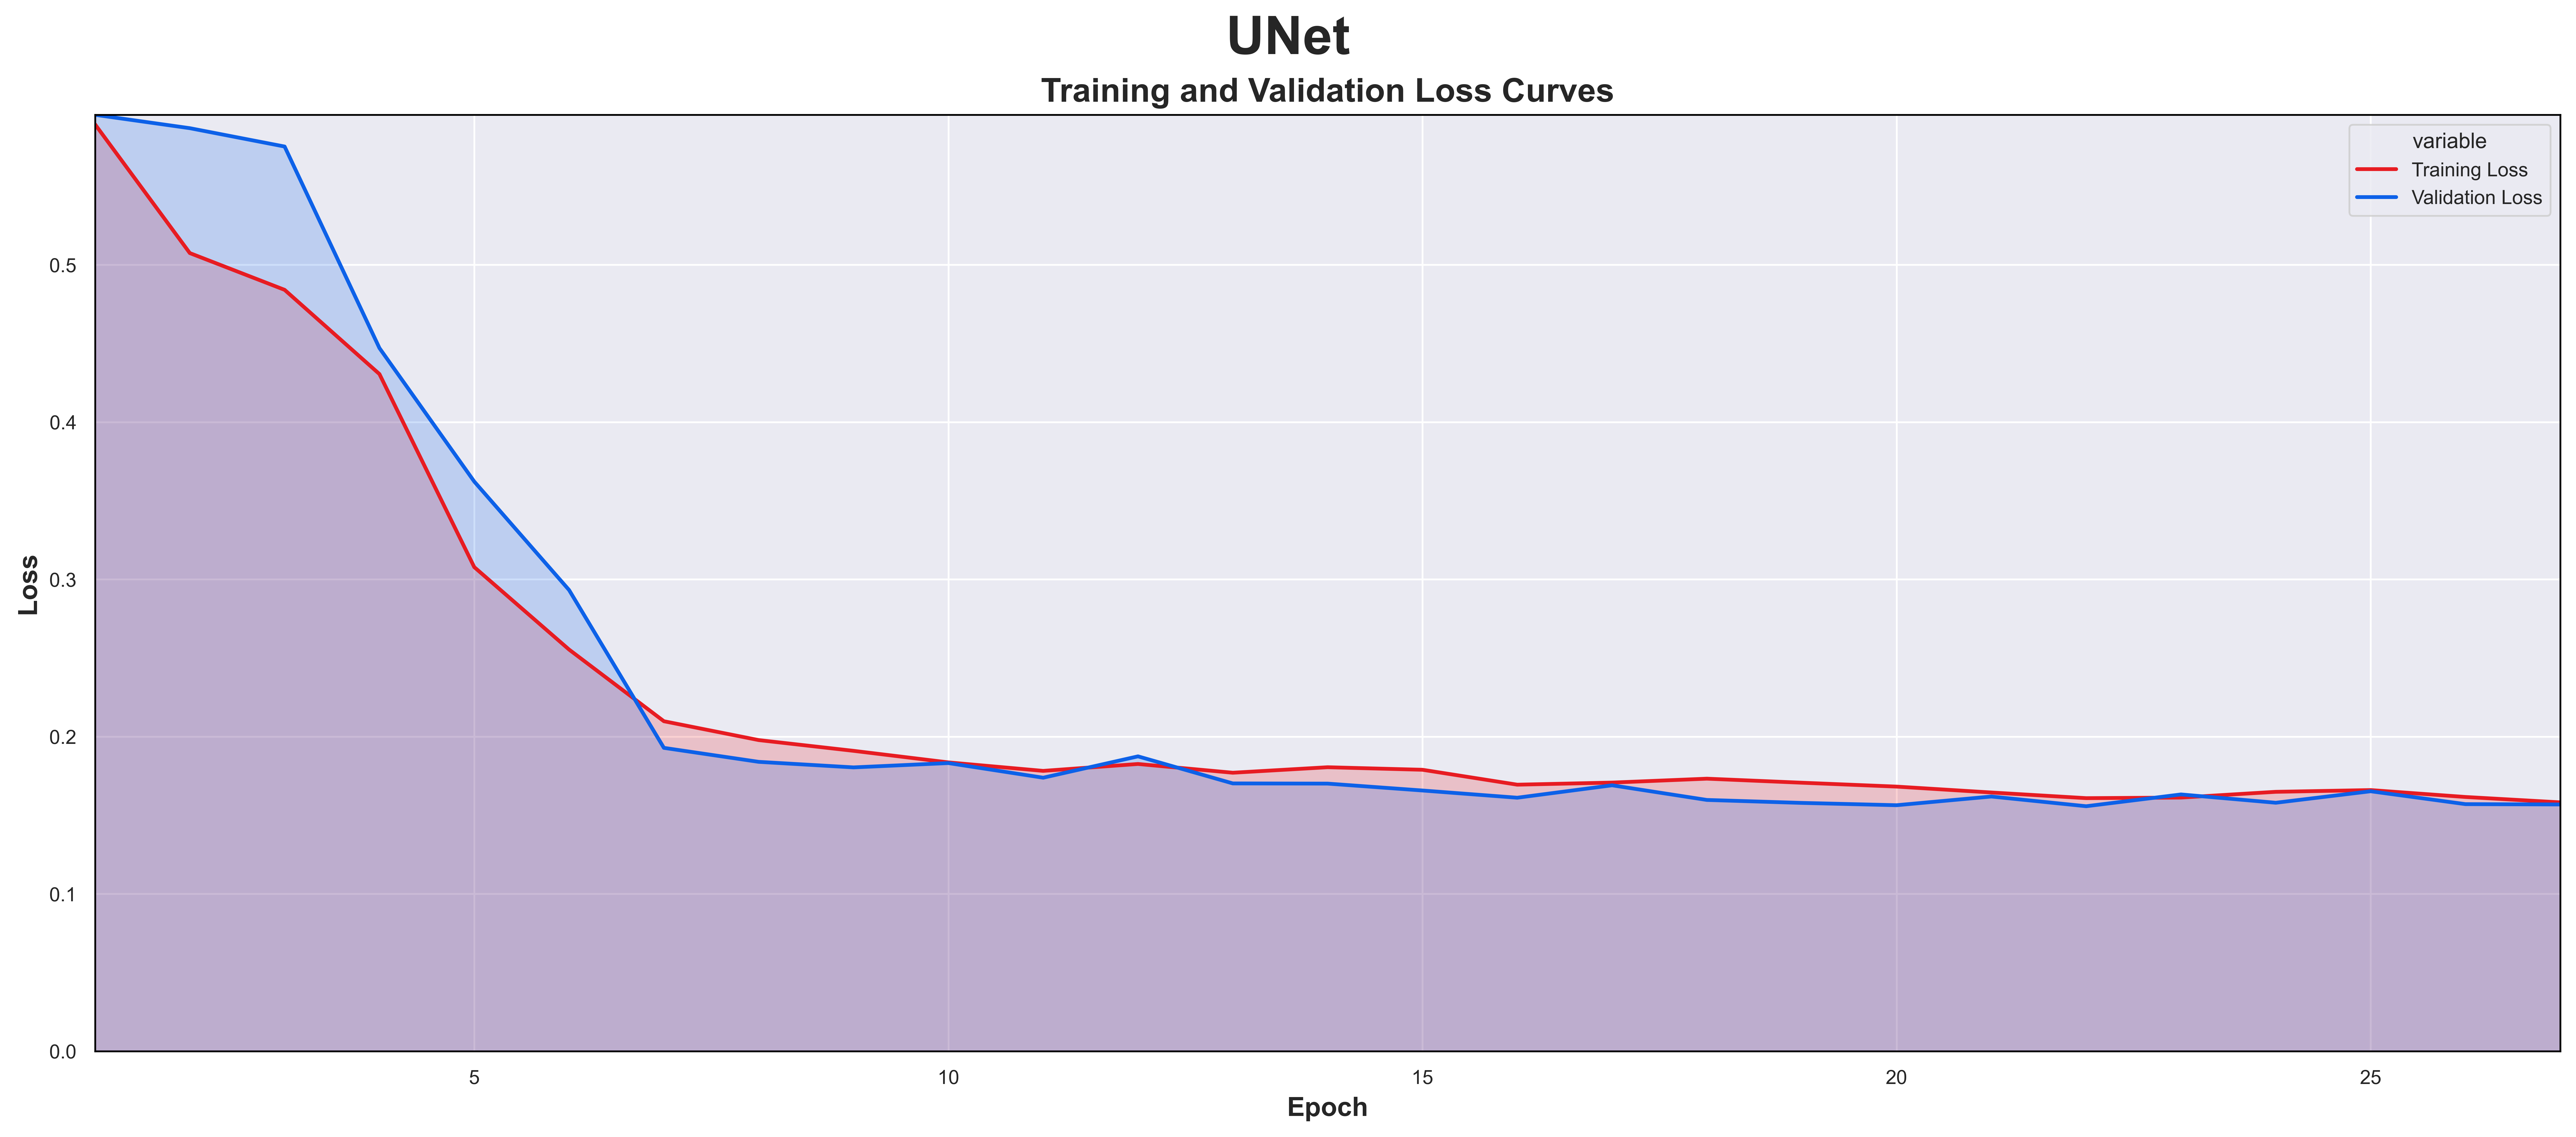

In [23]:
train_data = pd.DataFrame({
    'Epoch': range(1, len(train_log) + 1),
    'Training Loss': train_log,
    'Validation Loss': val_log
})

plot_loss_curve(train_data, title="UNet")

In [27]:
torch.save(unet.state_dict(), MODEL_PATH / "unet.pt")

In [9]:
state_dict = torch.load(MODEL_PATH / "unet.pt", map_location=device)
unet = UNet().to(device)
_ = unet.load_state_dict(state_dict)

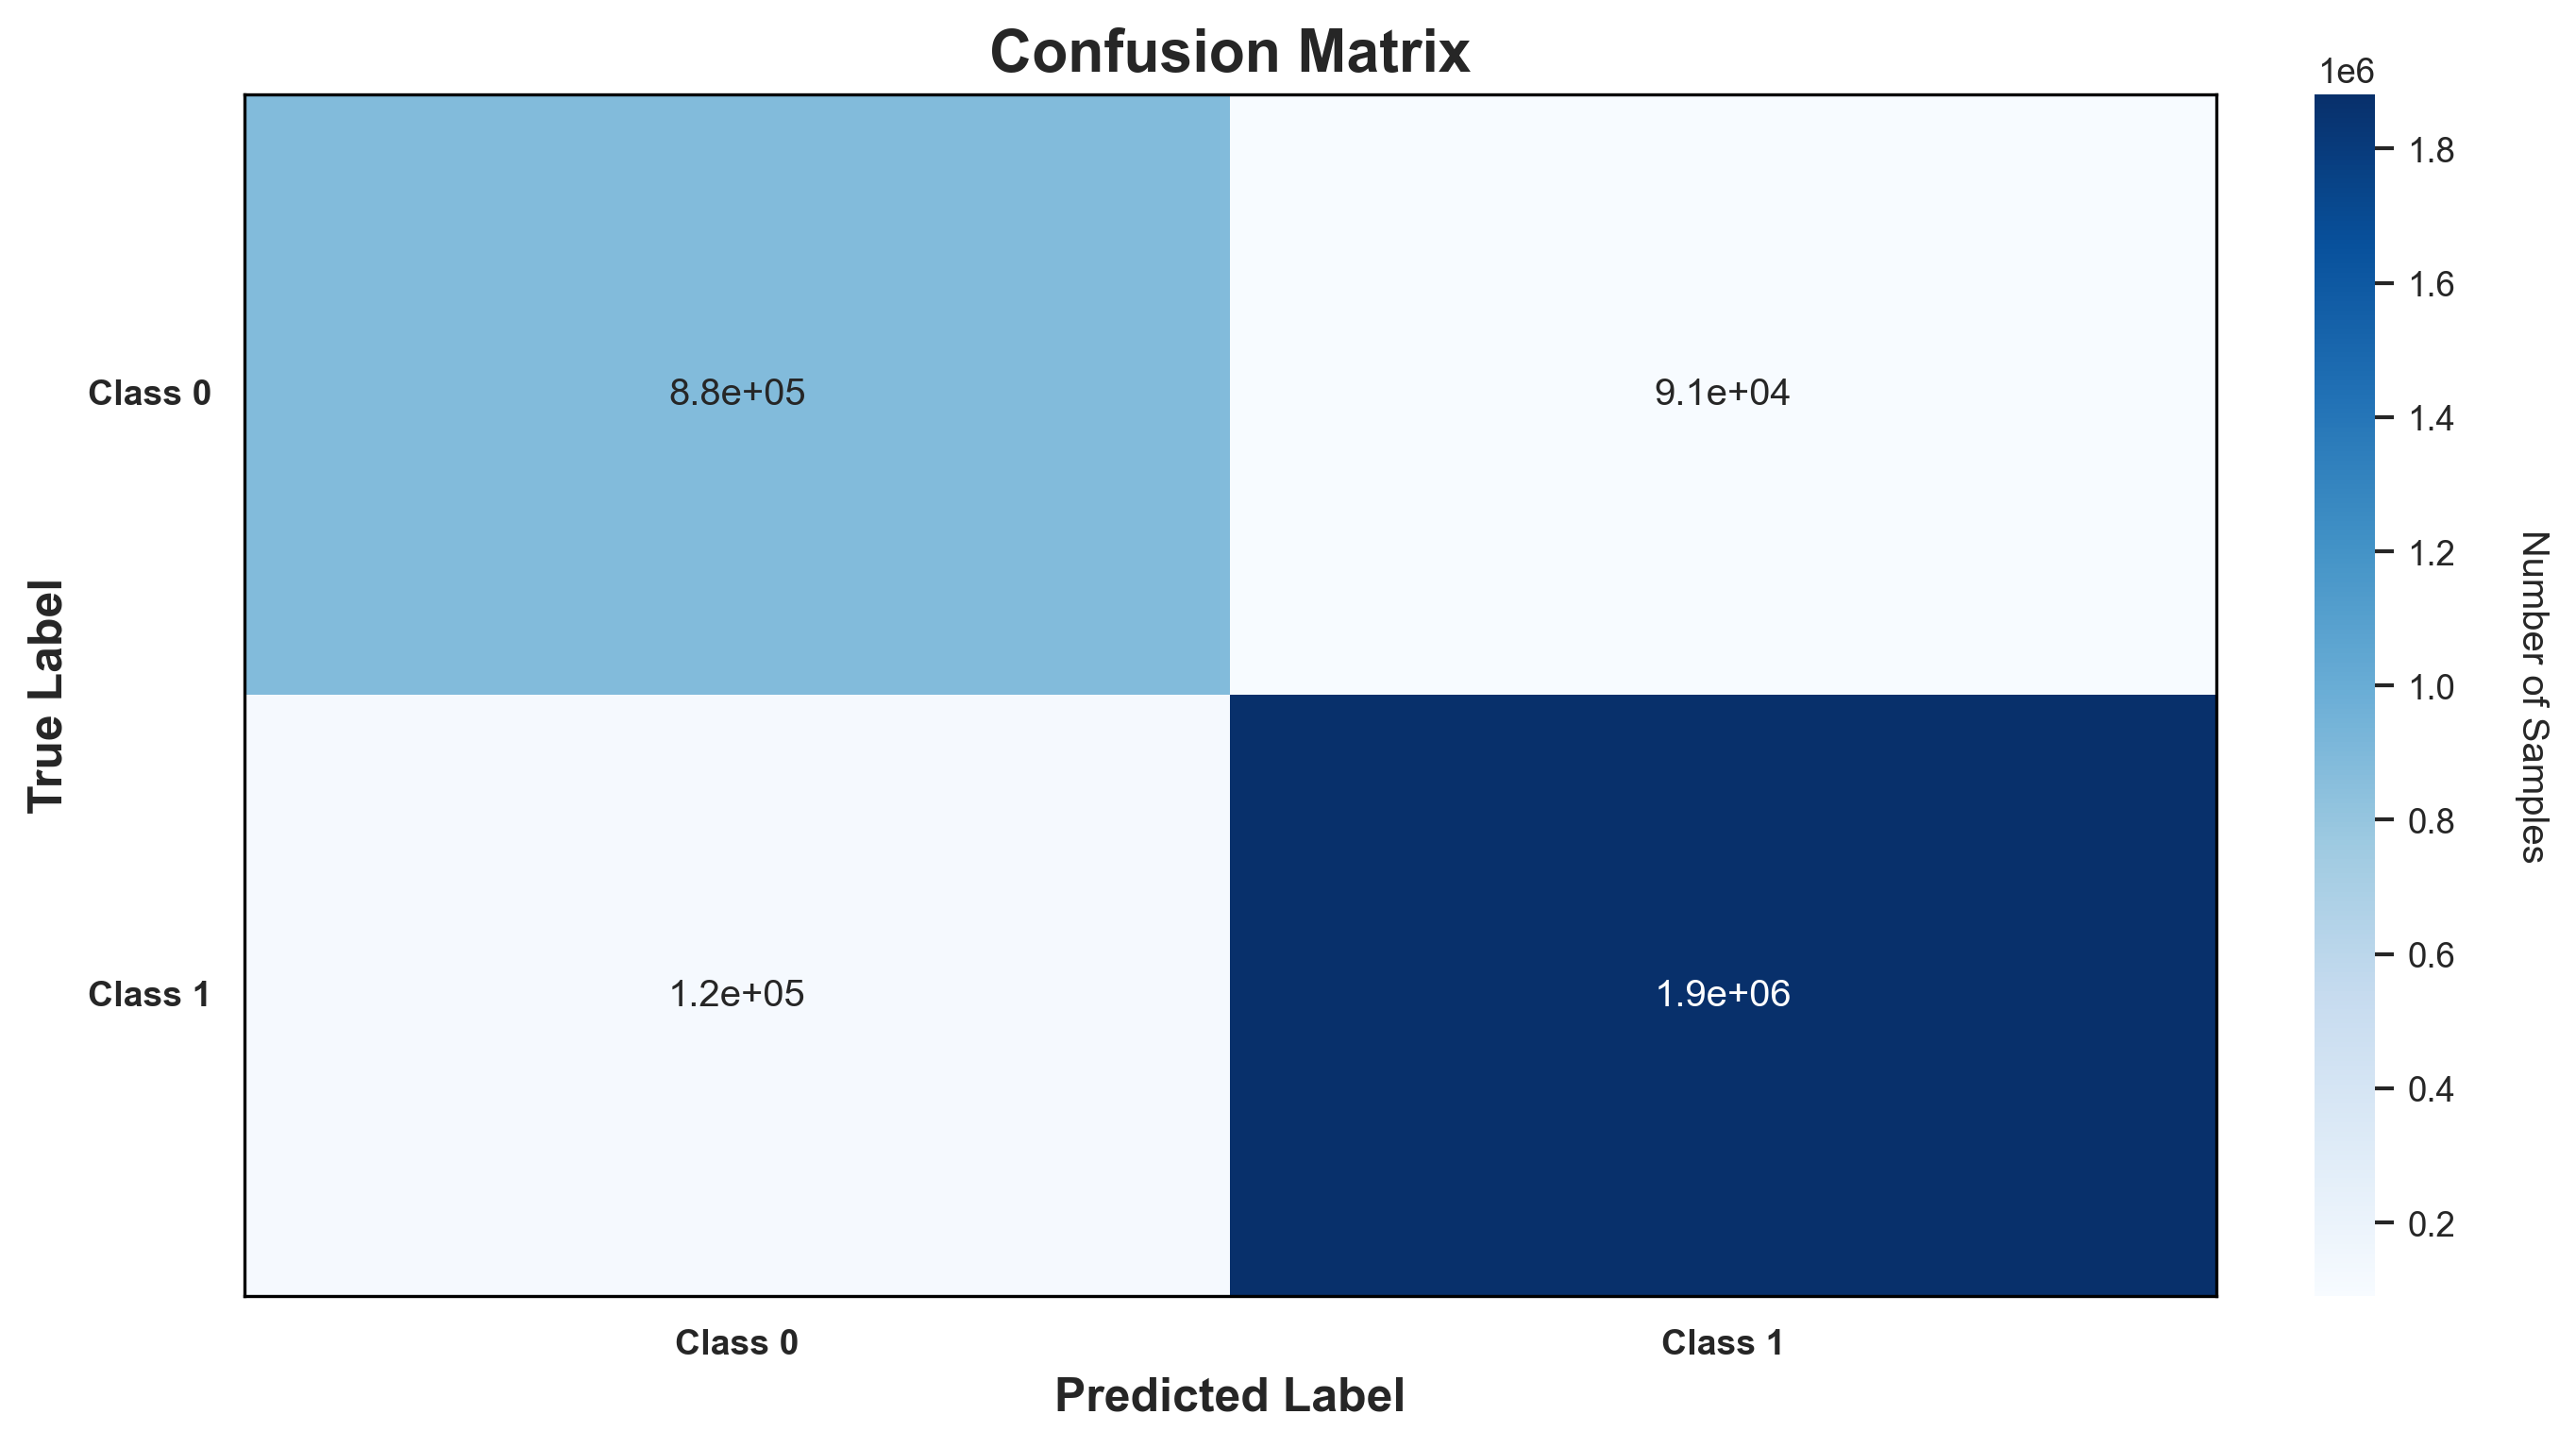

Unet Accuracy: 0.9296703496255165
|           |           0.0 |         1.0 |   accuracy |   macro avg |   weighted avg |
|:----------|--------------:|------------:|-----------:|------------:|---------------:|
| precision |      0.88207  | 0.953868    |    0.92967 |  0.917969   |     0.930328   |
| recall    |      0.906713 | 0.940868    |    0.92967 |  0.923791   |     0.92967    |
| f1-score  |      0.894222 | 0.947323    |    0.92967 |  0.920773   |     0.929914   |
| support   | 974953        | 1.99874e+06 |    0.92967 |  2.9737e+06 |     2.9737e+06 |


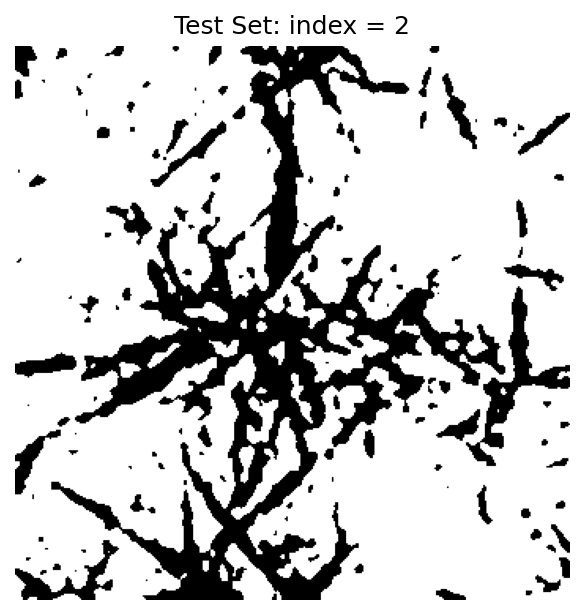

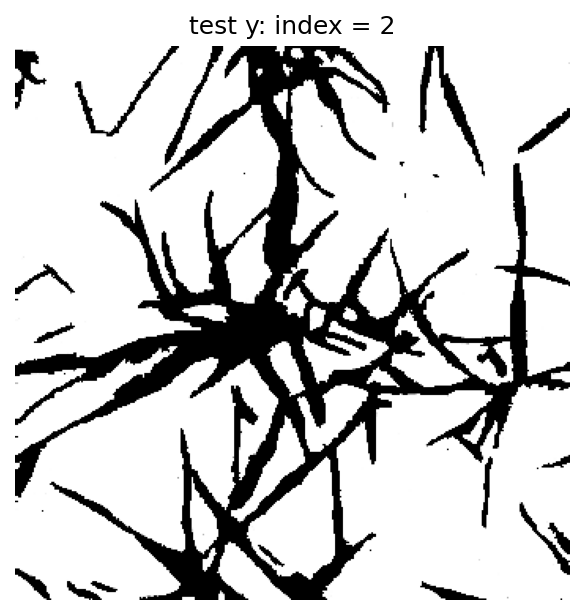

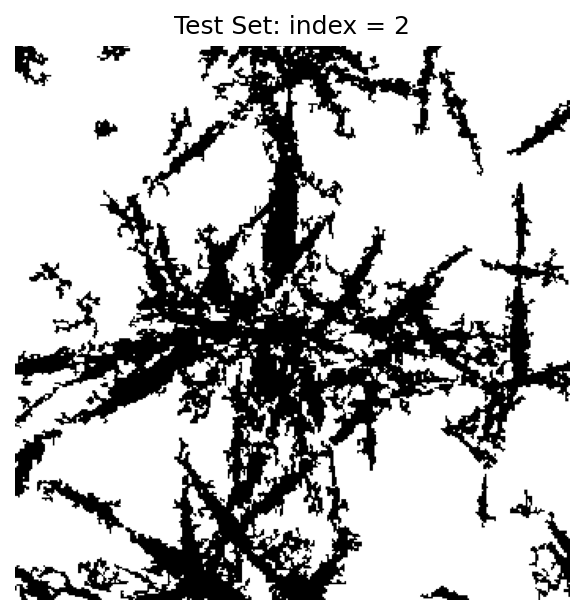

In [10]:
test_data = test_pipeline.get_data_loader(ground_truth=test_y, batch_size=1, shuffle=False, seed=SEED)
accuracy, confusion, report = evaluate_neural_network(unet, test_data, device=device, criteria=0.6)
plot_confusion_matrix(confusion, dpi=300)
print(f"Unet Accuracy: {accuracy}")
print(pd.DataFrame(report).to_markdown())

test_pipeline.set_unet_clf(unet).unet_predict(criteria=0.5, device=device).show(2)
ImagePipeline(test_y, ImageState.BINARY, title="test y").show(2)

exessive_green_method(test_pipeline).invert().show(2)
